<a href="https://colab.research.google.com/github/anujthapamagar/FEDS/blob/main/lecture3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/content')

import ffp2

In [4]:
df = pd.read_csv('/content/july_2nd_week.csv')

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import RobustScaler
from sklearn.datasets import make_blobs
from pylab import rcParams
plt.rcParams.update({'font.size': 14})

In [8]:
df["zma"] = df.zm - df.d
df["zmol"] = df.zm/df.L
df = df[df.u_star >= 0.2]
df = df[df.zmol >= -15.5]
df = df.dropna()
df = df.reset_index()

df.head()

,level_0,index,yyyy,mm,day,HH_UTC,MM,zm,d,z0,u_mean,L,sigma_v,u_star,wind_dir,date,zma,zmol
0,0,0,2015,7,8,0,15,70,13.4,-999,5.29407,843.062,1.621980,0.679911,224.847,2015-07-08,56.6,0.083031
1,1,1,2015,7,8,0,45,70,13.4,-999,5.14935,1137.760,1.270310,0.623401,227.603,2015-07-08,56.6,0.061524
2,2,2,2015,7,8,1,15,70,13.4,-999,5.33851,451.585,1.089680,0.507867,219.268,2015-07-08,56.6,0.155010
3,3,3,2015,7,8,1,45,70,13.4,-999,5.08884,313.622,0.812910,0.450874,221.224,2015-07-08,56.6,0.223199
4,4,4,2015,7,8,2,15,70,13.4,-999,4.58522,208.280,0.686362,0.352074,220.840,2015-07-08,56.6,0.336086


In [9]:
from tqdm import tqdm
res = []

for i in tqdm(range(len(df))):

    x_ci = ffp2.FFP(zm = df.zma[i],
                   z0 = None,
                   h = 1000.,
                   ol = df.L[i],
                   umean = df.u_mean[i],
                   sigmav = df.sigma_v[i],
                   ustar = df.u_star[i],
                   wind_dir = df.wind_dir[i],
                   nx = 1000)

    res.append(x_ci["x_ci_max"])

100%|██████████| 224/224 [00:05<00:00, 42.84it/s]


In [12]:
import matplotlib.pyplot as plt

x = np.sin(df.wind_dir.values*np.pi/180)*res
y = np.cos(df.wind_dir.values*np.pi/180)*res

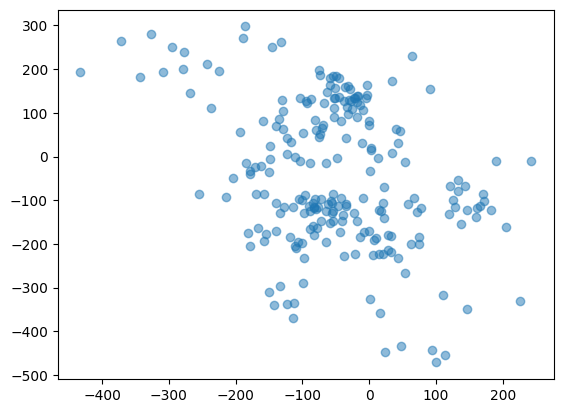

In [14]:
plt.scatter(x,y,alpha = 0.5)

In [15]:
df["x"] = pd.DataFrame(x)
df["y"] = pd.DataFrame(y)

In [16]:
df.head()

,level_0,index,yyyy,mm,day,HH_UTC,MM,zm,d,z0,u_mean,L,sigma_v,u_star,wind_dir,date,zma,zmol,x,y
0,0,0,2015,7,8,0,15,70,13.4,-999,5.29407,843.062,1.621980,0.679911,224.847,2015-07-08,56.6,0.083031,-114.666911,-115.280955
1,1,1,2015,7,8,0,45,70,13.4,-999,5.14935,1137.760,1.270310,0.623401,227.603,2015-07-08,56.6,0.061524,-127.382051,-116.303566
2,2,2,2015,7,8,1,15,70,13.4,-999,5.33851,451.585,1.089680,0.507867,219.268,2015-07-08,56.6,0.155010,-138.936648,-169.940972
3,3,3,2015,7,8,1,45,70,13.4,-999,5.08884,313.622,0.812910,0.450874,221.224,2015-07-08,56.6,0.223199,-155.321063,-177.271939
4,4,4,2015,7,8,2,15,70,13.4,-999,4.58522,208.280,0.686362,0.352074,220.840,2015-07-08,56.6,0.336086,-177.847751,-205.748033


In [17]:
##df.tocsv("July_2nd_week_xy.csv")

In [34]:
X = df[["x", "y"]].values

In [35]:
Xs = RobustScaler().fit_transform(X)

In [39]:
hdb = HDBSCAN(min_cluster_size=10, min_samples=10)

In [40]:
hdb.fit(Xs)
labels = hdb.fit_predict(X)

print(labels)

[ 1  1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1
 -1 -1 -1 -1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1  1  1 -1 -1  1 -1
  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1  2 -1 -1 -1  2
 -1  2  2  2 -1  2  2  2  2  2  2 -1  2  2  2  2  2  2  2 -1 -1  2  2  2
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2  2  2 -1 -1 -1  2  2  2
  2 -1  2  2  2  2  2  2  2  2  2 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1  2  2
 -1 -1  2 -1  2  2  2 -1 -1 -1 -1 -1  2  2  2 -1  2  2 -1 -1 -1 -1 -1  0
 -1  1 -1 -1 -1 -1  2 -1]


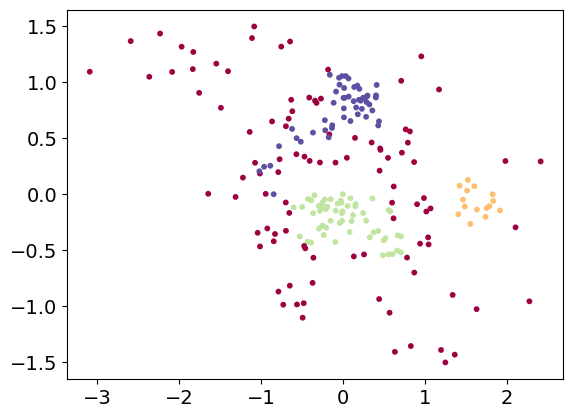

In [41]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Spectral', s=10)
plt.show()

In [45]:
def plot_hdbscan_results(X, labels):
    plt.figure(figsize=(7, 7))

    # Noise points
    noise = labels == -1
    plt.scatter(
        X[noise, 0],
        X[noise, 1],
        c='black',
        s=10,
        label='noise'
    )

    # Clustered points
    clusters = labels != -1
    plt.scatter(
        X[clusters, 0],
        X[clusters, 1],
        c=labels[clusters],
        cmap='Spectral',
        s=10
    )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    plt.title(f"HDBSCAN clusters: {n_clusters}")
    plt.legend()
    plt.tight_layout()
    plt.show()

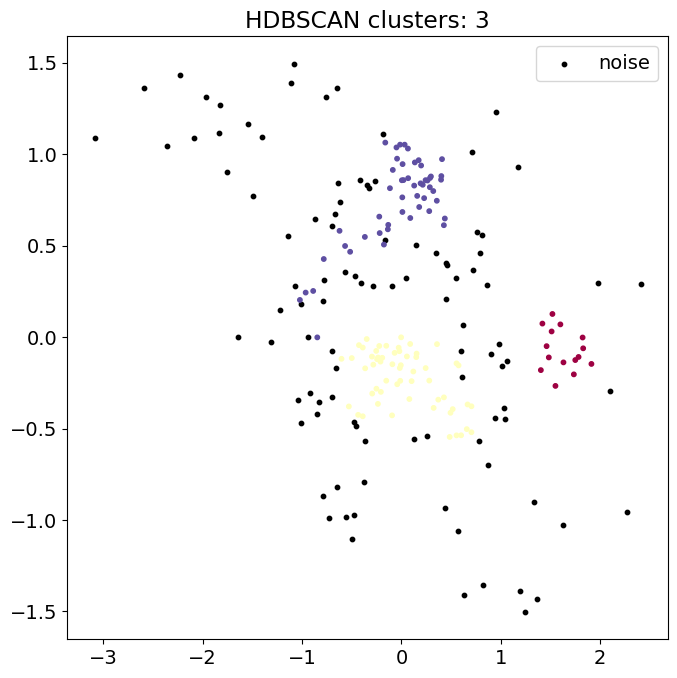

In [47]:
hdb = HDBSCAN(min_cluster_size=10, min_samples=10)

labels = hdb.fit_predict(X)
probs = hdb.probabilities_
plot_hdbscan_results(X, labels)